In [1]:
import matplotlib.pyplot as plt
# from erddapClient import ERDDAP_Griddap
from netCDF4 import Dataset
import numpy as np
import xarray as xr
import pandas as pd

from mpl_toolkits.basemap import Basemap

In [28]:
# df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_2mad_20260329.csv')
#df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_exp_2p_1mad_20260418.csv')
# df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_exp_2p_1mad_20260423.csv')
df = pd.read_csv('/home/jamesash/projects/climate/data/summary_statistics/bloom_summary_2p_1mad_20260423.csv')

In [29]:
df["ture_area_km2"] = df["max_area_km2"] + (df["cloud_pct"] * df["max_area_km2"]/100)

In [30]:
# Global Ocean Colour (Copernicus-GlobColour), Bio-Geo-Chemical, L4 (monthly and interpolated) from Satellite Observations (Near Real Time)
file_id = Dataset('/home/jamesash/projects/climate/data/chl/climate_slope/cli_day_sum_20240118.nc')
ras = file_id.variables["cli_day_sum_20240118"][:]
#mask = file_id.variables["mask"][:]
lat = file_id.variables["latitude"][:]
lon = file_id.variables["longitude"][:]
file_id.close()

# convert to xarray. 
ras = xr.DataArray(ras[1,:,:], 
                   coords={'x': lat, 'y':lon}, 
                   dims=["x", "y"])
# copy but just have NA values for a white graph. 
na_ras = xr.full_like(ras, fill_value = np.nan)

/tmp/ipykernel_879395/249767097.py:48: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  m.scatter(x_pts, y_pts, c=colors, s=20, marker='x', edgecolors='black',


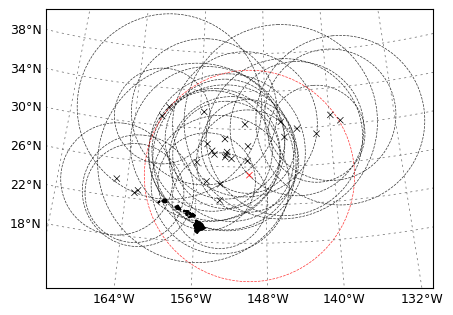

In [32]:
# Create figure and map
fig, ax1 = plt.subplots(1, 1, figsize=(5, 6))
m = Basemap(projection='lcc', resolution='h', 
            llcrnrlat=11.5, urcrnrlat=40.5, 
            llcrnrlon=-171, urcrnrlon=-124.5,
            lat_0=30, lon_0=-150,
            width=5.1E6, height=5E6)

# Convert latitude and longitude to map projection coordinates
x_map, y_map = np.meshgrid(na_ras.y, na_ras.x)
x, y = m(x_map, y_map)

# Plot the base contour (even if NaN, sets up the map)
contour = m.contourf(x, y, na_ras, extend='both')
m.fillcontinents(color='black')

# Add grid lines
parallels = m.drawparallels(np.arange(18, 40, 4), labels=[1,0,0,0], 
                            textcolor='black', color="dimgrey", fontsize=9, 
                            dashes=(3, 5), linewidth=0.5)
meridians = m.drawmeridians(np.arange(-172, -126, 8), labels=[0,0,0,1], 
                            textcolor='black', color="dimgrey", fontsize=9, 
                            dashes=(3, 5), linewidth=0.5)
m.drawcoastlines(color='black')

# Calculate radius from area (area = pi * r^2, so r = sqrt(area / pi))
# Assuming area is in km², radius will be in km
df['radius_km'] = np.sqrt(df["ture_area_km2"] / np.pi) / 100

# Draw circles using tissot (which accounts for map projection)
# tissot takes: lon, lat, radius_in_km
for idx, row in df.iterrows():
    is_2018 = row['start'].startswith('2018')
    circle_color = 'red' if is_2018 else 'black'
    m.tissot(row['center_lon'], row['center_lat'], row['radius_km'], 100,
             facecolor='none', 
             edgecolor=circle_color, 
             linestyle="--",
             linewidth=0.5, 
             alpha = 0.8)
    #print(row['radius_km'])

# Create color array for scatter points
colors = ['red' if start.startswith('2018') else 'black' for start in df['start']]

# Convert CSV lat/lon to map projection coordinates and plot center points
x_pts, y_pts = m(df['center_lon'].values, df['center_lat'].values)
m.scatter(x_pts, y_pts, c=colors, s=20, marker='x', edgecolors='black', 
          linewidth=0.5)
plt.savefig('../../figures/bloom_centers_1mad_2p_20260418.pdf', format='pdf', bbox_inches='tight', dpi=600)
plt.savefig('../../figures/bloom_centers_1mad_2p_20260418.png', format='png', bbox_inches='tight', dpi=600)
plt.show()

In [26]:
df

,start,end,center_date,center_lat,center_lon,magnitude,max_area_km2,max_area_date,cloud_pct,ture_area_km2,radius_km
0,1998-07-08,1998-10-06,1998-08-09,22.645832,-163.104172,0.115415,4.575736e+05,1998-07-17,85.57,8.491193e+05,5.198876
1,1999-08-01,1999-10-12,1999-09-05,29.395832,-142.145828,0.147126,5.114299e+05,1999-10-05,62.03,8.286698e+05,5.135891
2,2000-08-15,2000-11-15,2000-09-19,26.270832,-155.812500,0.234188,7.367609e+05,2000-10-30,71.62,1.264429e+06,6.344133
3,2001-07-18,2001-08-04,2001-07-24,24.562498,-155.395828,0.091775,4.721862e+05,2001-07-22,76.05,8.312839e+05,5.143986
4,2002-06-15,2002-09-10,2002-08-03,27.645832,-154.395828,0.115844,8.183421e+05,2002-08-17,56.08,1.277268e+06,6.376262
5,2003-07-26,2003-10-08,2003-08-10,26.979164,-139.145828,0.153709,1.141207e+06,2003-09-25,38.67,1.582512e+06,7.097389
6,2004-06-03,2004-08-11,2004-07-12,29.312498,-145.229172,0.136719,1.472241e+06,2004-07-22,46.79,2.161103e+06,8.293976
7,2005-07-02,2005-10-02,2005-08-31,22.395832,-153.270828,0.137192,4.902706e+05,2005-09-18,61.41,7.913457e+05,5.018896
8,2006-07-22,2006-11-11,2006-09-01,26.979164,-152.854172,0.126602,1.114971e+06,2006-10-30,65.34,1.843493e+06,7.660301
9,2007-08-15,2007-11-07,2007-09-27,31.770832,-155.645828,0.234072,1.281357e+06,2007-10-31,46.32,1.874882e+06,7.725241
